In [172]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [173]:
nr_of_seeds = 10 #nr of seeds in the experiments

In [174]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [175]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13140\1856811554.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13140\1856811554.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

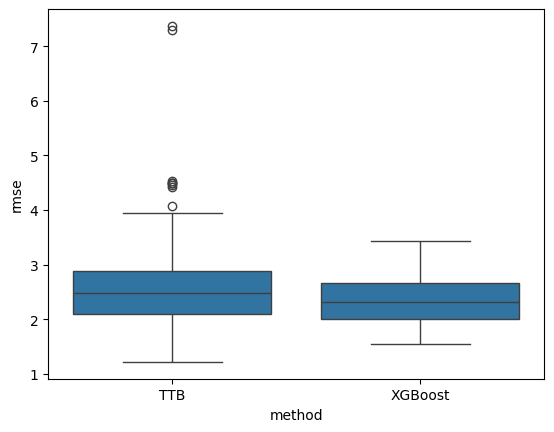

In [176]:


dat = pd.read_csv(f'results/ttb_9.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_9.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse')





In [177]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
700,0.1,2.0,1.0,0.01,0.9,2.194981,1.690405,10,859.0,400.0,2.321230,1.995518,1.831390,1.492333,TransferTreeBoost
579,0.1,2.0,1.0,0.01,0.9,2.194981,1.690405,10,858.0,400.0,2.288458,1.936859,2.101189,1.565623,TransferTreeBoost
524,0.1,2.0,1.0,0.01,0.9,2.194981,1.690405,10,857.0,400.0,1.479740,1.158788,2.131046,1.512453,TransferTreeBoost
60,0.1,2.0,1.0,0.01,0.9,2.194981,1.690405,10,850.0,400.0,2.170813,1.741663,1.798554,1.446462,TransferTreeBoost
476,0.1,2.0,1.0,0.01,0.9,2.194981,1.690405,10,856.0,400.0,3.506534,2.974200,2.920530,2.390779,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,0.1,3.0,2.0,0.01,0.9,2.842959,2.124701,10,854.0,400.0,2.203904,1.604493,2.675443,2.000863,TransferTreeBoost
204,0.1,3.0,2.0,0.01,0.9,2.842959,2.124701,10,852.0,400.0,3.487496,2.471513,2.874525,1.984370,TransferTreeBoost
499,0.1,3.0,2.0,0.01,0.9,2.842959,2.124701,10,856.0,400.0,5.832335,4.515931,7.293716,5.259161,TransferTreeBoost
404,0.1,3.0,2.0,0.01,0.9,2.842959,2.124701,10,855.0,400.0,2.981390,2.368197,2.432413,1.896988,TransferTreeBoost


In [178]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,2.206436,1.702412,10,2,850.0,3.032798,2.134519,1.551092,1.216175,XGBoost
8,0.1,3.0,2.206436,1.702412,10,8,851.0,3.275646,2.156959,2.650674,1.964984,XGBoost
14,0.1,3.0,2.206436,1.702412,10,14,852.0,3.859474,2.767880,2.127306,1.587119,XGBoost
20,0.1,3.0,2.206436,1.702412,10,20,853.0,1.638587,1.391792,1.817226,1.395558,XGBoost
26,0.1,3.0,2.206436,1.702412,10,26,854.0,2.808417,2.110949,2.414843,1.915076,XGBoost
44,0.1,3.0,2.206436,1.702412,10,44,857.0,1.374788,1.026656,2.796665,2.084964,XGBoost
38,0.1,3.0,2.206436,1.702412,10,38,856.0,1.987635,1.745999,2.184002,1.930300,XGBoost
32,0.1,3.0,2.206436,1.702412,10,32,855.0,1.869486,1.392751,2.253093,1.547020,XGBoost
50,0.1,3.0,2.206436,1.702412,10,50,858.0,1.963074,1.644632,2.002052,1.494794,XGBoost
56,0.1,3.0,2.206436,1.702412,10,56,859.0,1.908241,1.557476,2.267402,1.888126,XGBoost
